# DNN(Deep Neural Network) 심층신경망을 이용한 MNist(손글씨)분석

[심층신경망에 대한 설명](https://heung-bae-lee.github.io/2019/12/08/deep_learning_03/)

[영상자료](https://www.youtube.com/watch?v=aircAruvnKk)

# Chapter1. MNist 심층신경망

## 1) MNist데이터는 어떻게 이루어져 있나?

MNIST데이터의 갯수는 몇개이고 어떻게 이루어져 있을까?

In [ ]:
# 1. 데이터 불러오기
import tensorflow as tf
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data() # mnist 손글씨 데이터 10개의 범주가 있다.

11490434/11490434 [==============================] - 0s 0us/step


In [ ]:
print(train_input.shape, train_target.shape) # 훈련데이터
print(test_input.shape, test_target.shape) # 테스트데이터

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
import numpy as np
print(np.unique(train_target, return_counts=True)) #레이블당 데이터의 개수

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))


첫번째 데이터는 어떤 것일까?

In [ ]:
print(train_target[0]) # 첫번째 훈련데이터 값은 무엇일까?

5


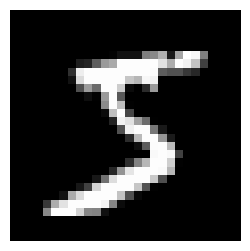

In [ ]:
import matplotlib.pyplot as plt # 데이터 시각화 불러오기
plt.figure(figsize = (3, 3)) # 사이즈를 가로 사이즈 3, 세로 사이즈 3로 나타낼것
plt.imshow(train_input[0], cmap = 'gray') # train_input[0]의 데이터를 흑백으로 나타낼것
plt.axis('off') # 추세선 제거
plt.show() # 시각화 하기

처음 10개의 데이터는 어떤 것이 있을까?

In [ ]:
print([train_target[i] for i in range(10)]) # 10개의 훈련데이터 값은 무엇일까?

[5, 0, 4, 1, 9, 2, 1, 3, 1, 4]


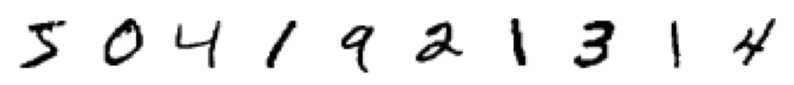

In [ ]:
fig, axs = plt.subplots(1, 10, figsize = (10, 10)) # 10개의 그림을 1행으로 나열
for i in range(10): # 0~9까지 10개의 연속적인 숫자나열
    axs[i].imshow(train_input[i], cmap = 'gray_r') # train_input의 i번째 데이터 보여주고, 흑백 반전으로 보일것
    axs[i].axis('off') # 추세선 제거
plt.show() # 시각화

## 2) **심층 신경망 만들기**

입력층과 출력층 사이에 밀집층을 하나 추가해보자.이런 층을 '은닉층(hidden layer)'라고 부른다.

예를 들어 은닉층의 뉴런을 100개 만든다면 각 뉴런은 입력층으로부터 784개의 데이터를 입력받아

$$z = w_1 \times {\rm pixel_1 } + \ldots + w_{784} \times {\rm pixel_{784}} + b $$

를 얻고 이렇게 만든 100개의 $z_1 , \ldots, z_{100} $ 들을 각각 활성화함수를 써서 $h_{1} , \ldots, h_{100} $으로 변환한다. 다음 코드 가운데 `hidden`이 은닉층을 나타낸다.

이어서 출력층에서는 은닉층에서 나온 100개의 입력을 가지고 10개의

$$ z = w_1 \times \phi(h_1) + \ldots + w_{100} \times \phi(h_{100}) + b $$

를 만들고 softmax 활성화함수로 10개 범주의 예측확률($a_1 , \ldots, a_{10} $)을 구한다. 은닉층과 출력층은 역시 `keras.layers`에 있는 `Dense()`를 이용해서 만들면 된다.

In [ ]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()

In [ ]:
#2. 데이터 표준화
train_scaled = train_input / 255.0 # 표준화 0~1사이 값

In [ ]:
#3. 훈련데이터 및 검증데이터 나누기
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5) # 훈련데이터와 검증데이터를 5:5로 나눈다.

데이터 분할을 5:5 인 이유? 설명할때 일반적인경우에는 7:3이나 8:2로하는데, 지금데이터는 수가 많고 이미 잘섞여있는 데이터여서 5:5비율은 과적합이 안일어난다.또한 훈련데이터수가 줄어들어 에포크시 소요시간도 줄어듬

In [ ]:
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(30000, 28, 28) (30000,)
(30000, 28, 28) (30000,)


심층신경망을 만들기 위해선 '활성화함수'를 사용해야 하는데, 어떤 활성화 함수를 이용해야 하나?

**심층신경망 층을 만들 때 사용하는 활성화 함수**

ReLU(Rectified Linear Unit) 함수와 Leaky ReLU(Leaky Rectified Linear Unit) 함수는 둘 다 주로 인공 신경망의 은닉층에서 사용되는 활성화 함수입니다. 그러나 두 함수 간에는 중요한 차이가 있습니다.


**렐루 (ReLU) 함수 (Rectified Linear Unit)**

ReLU 함수는 입력이 양수인 경우에는 입력 값을 그대로 반환하고, 음수인 경우에는 0으로 만듭니다.
수학적으로는 다음과 같이 정의됩니다.

$$ \phi (z) = \max (0, z) $$

주요 장점은 계산이 간단하며, 경사 하강법을 통한 학습이 빠르게 이루어질 수 있습니다.
그러나 입력이 음수인 경우에 해당 뉴런이 활성화되지 않기 때문에, 음수 값에 대한 정보 손실이 발생할 수 있습니다. 이것이 "죽은 렐루(dying ReLU)" 문제로 알려져 있습니다.

**리키렐루 (Leaky ReLU) 함수 (Leaky Rectified Linear Unit)**

Leaky ReLU 함수는 ReLU의 단점을 해결하기 위해 도입되었습니다.
**Leaky ReLU는 입력이 음수인 경우에도 작은 기울기를 갖도록 설계되어 있습니다.** 이러한 기울기는 보통 0에 가까운 작은 상수로 설정됩니다.
수학적으로는 다음과 같이 정의됩니다.

$$ \phi (z) = \max (αz, z) $$


여기서 α (alpha)는 작은 양수 값입니다.
이로 인해 음수 값에 대한 정보 손실이 감소하고, 죽은 렐루 문제를 완화할 수 있습니다.
따라서 Leaky ReLU는 ReLU의 주요 이점을 유지하면서 죽은 렐루 문제를 완화하는데 사용될 수 있습니다. 하지만 **어떤 함수를 사용할지는 데이터나 모델에 따라 다를 수 있으며, 실험적으로 성능을 비교하여 결정하는 것이 일반적입니다.**
이로 인해 음수 값에 대한 정보 손실이 감소하고, 죽은 렐루 문제를 완화할 수 있습니다.

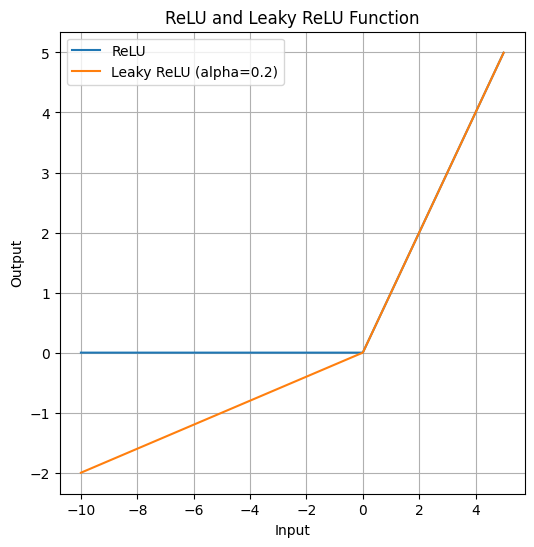

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ReLU 함수 정의
def relu(x):
    return np.maximum(0, x) # np.maximum() : 배열 인덱싱에서 가장 큰 수를 할당해주는 메서드

# Leaky ReLU 함수 정의
def leaky_relu(x, alpha=0.2):
    return np.maximum(alpha*x, x)

# x 값 생성
x_values = np.arange(-10, 5, 0.005)

# ReLU 함수 값 계산
relu_values = relu(x_values)

# Leaky ReLU 함수 값 계산
leaky_relu_values = leaky_relu(x_values)

# 그래프 그리기
plt.figure(figsize=(6, 6))
plt.plot(x_values, relu_values, label='ReLU')
plt.plot(x_values, leaky_relu_values, label='Leaky ReLU (alpha=0.2)')
plt.title('ReLU and Leaky ReLU Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# np.maximum과 np.max의 차이점

import numpy as np
a = np.array([10, 20, 50])
b = np.array([30, 60, 80])

np.maximum(a,b)
np.max(a)

array([30, 60, 80])

In [ ]:
# 4. 리키 렐루함수를 이용한 첫번째 은닉층 만들기, 두번째 은닉층 및 출력층 만들기
model = keras.Sequential(name = "MNist") # 모델 층 정의
model.add(keras.layers.Flatten(input_shape=(28, 28))) # 입력데이터를 2차원 배열에서 1차원 배열로 차원을 축소
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1")) # 256개의 뉴런과 리키렐루함수를 이용하는 첫번째 은닉층
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2")) # 64개의 뉴런과 렐루함수를 이용하는 두번째 은닉층
model.add(keras.layers.Dense(10, activation='softmax', name = "output")) # 10개의 뉴런과 소프트맥스 함수를 이용하는 출력층

In [ ]:
model.summary() # parameter수 결과

Model: "MNist"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 hidden_1 (Dense)            (None, 256)               200960    
                                                                 
 hidden_2 (Dense)            (None, 64)                16448     
                                                                 
 output (Dense)              (None, 10)                650       
                                                                 
Total params: 218058 (851.79 KB)
Trainable params: 218058 (851.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
938/938 [==============================] - 9s 4ms/step - loss: 0.3003 - accuracy: 0.9114
Epoch 2/5
938/938 [==============================] - 3s 3ms/step - loss: 0.1404 - accuracy: 0.9571
Epoch 3/5
938/938 [==============================] - 4s 4ms/step - loss: 0.1028 - accuracy: 0.9690
Epoch 4/5
938/938 [==============================] - 4s 4ms/step - loss: 0.0769 - accuracy: 0.9761
Epoch 5/5
938/938 [==============================] - 3s 3ms/step - loss: 0.0618 - accuracy: 0.9813


에포크 값이 938인 이유? 훈련데이터와 검증데이터를 5:5로 나누어 훈련데이터는 (30000, 28, 28)을 이룬다. 케라스의 미니배치 기본값이 32이므로, 30000/32 = 937.5 이기 때문에, 938 이 나왔다. (미니배치 값을 바꾸고 싶다면, fit()메서드 에서 batch_size를 이용하여 바꿀수있다.)

In [ ]:
model.evaluate(val_scaled, val_target)

938/938 [==============================] - 3s 3ms/step - loss: 0.1203 - accuracy: 0.9668


[0.12033666670322418, 0.9667999744415283]

## **3) 옵티마이저**

* **하이퍼 파라미터 : 모델이 학습하지 않고 사람이 정해주어야하는 파라미터.**

In [ ]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5)

model = keras.Sequential(name = "MNist")
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1"))
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2"))
model.add(keras.layers.Dense(10, activation='softmax', name = "output"))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
938/938 [==============================] - 4s 3ms/step - loss: 0.3082 - accuracy: 0.9093
Epoch 2/5
938/938 [==============================] - 3s 3ms/step - loss: 0.1351 - accuracy: 0.9601
Epoch 3/5
938/938 [==============================] - 7s 8ms/step - loss: 0.0922 - accuracy: 0.9719
Epoch 4/5
938/938 [==============================] - 3s 4ms/step - loss: 0.0679 - accuracy: 0.9793
Epoch 5/5
938/938 [==============================] - 3s 3ms/step - loss: 0.0517 - accuracy: 0.9840


In [ ]:
model.evaluate(val_scaled, val_target)

938/938 [==============================] - 3s 3ms/step - loss: 0.1321 - accuracy: 0.9628


[0.13208387792110443, 0.9628000259399414]

# **Chapter2. MNist모델 훈련 및 검증**

## **1) 손실곡선**

In [ ]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5)

model = keras.Sequential(name = "MNist")
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1"))
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2"))
model.add(keras.layers.Dense(10, activation='softmax', name = "output"))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=10)

Epoch 1/10
938/938 [==============================] - 5s 4ms/step - loss: 0.3072 - accuracy: 0.9102
Epoch 2/10
938/938 [==============================] - 3s 3ms/step - loss: 0.1351 - accuracy: 0.9592
Epoch 3/10
938/938 [==============================] - 3s 3ms/step - loss: 0.0959 - accuracy: 0.9708
Epoch 4/10
938/938 [==============================] - 3s 3ms/step - loss: 0.0684 - accuracy: 0.9780
Epoch 5/10
938/938 [==============================] - 3s 3ms/step - loss: 0.0532 - accuracy: 0.9823
Epoch 6/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0411 - accuracy: 0.9856
Epoch 7/10
938/938 [==============================] - 3s 3ms/step - loss: 0.0357 - accuracy: 0.9883
Epoch 8/10
938/938 [==============================] - 3s 3ms/step - loss: 0.0315 - accuracy: 0.9895
Epoch 9/10
938/938 [==============================] - 3s 3ms/step - loss: 0.0232 - accuracy: 0.9922
Epoch 10/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0218 - accuracy: 0.9921

In [ ]:
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


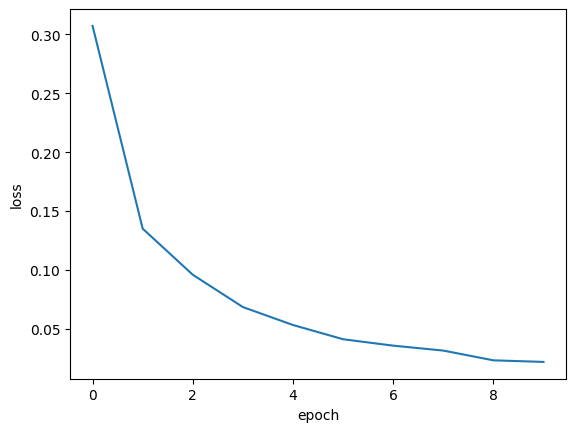

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

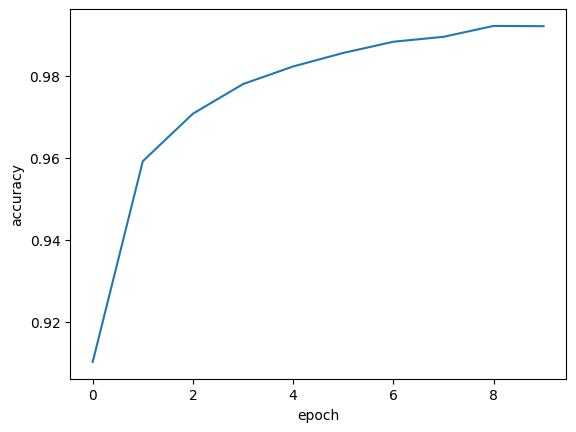

In [ ]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

## **2) 검증손실**

In [ ]:
# 층만 추가하였을때 검증손실
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5)

model = keras.Sequential(name = "MNist")
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1"))
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2"))
model.add(keras.layers.Dense(10, activation='softmax', name = "output"))

model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

In [ ]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


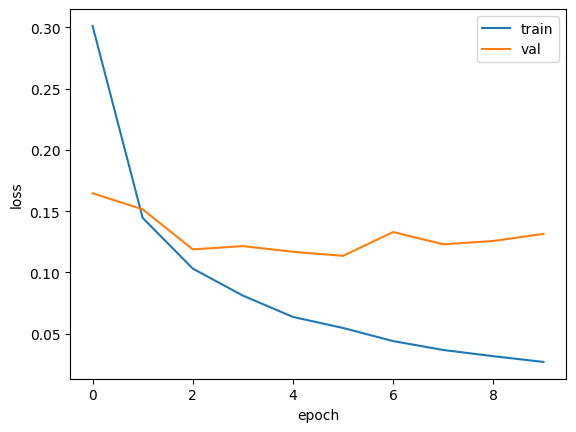

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
# 옵티마이저를 추가하였을때 검증손실
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5)

model = keras.Sequential(name = "MNist")
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1"))
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2"))
model.add(keras.layers.Dense(10, activation='softmax', name = "output"))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

In [ ]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


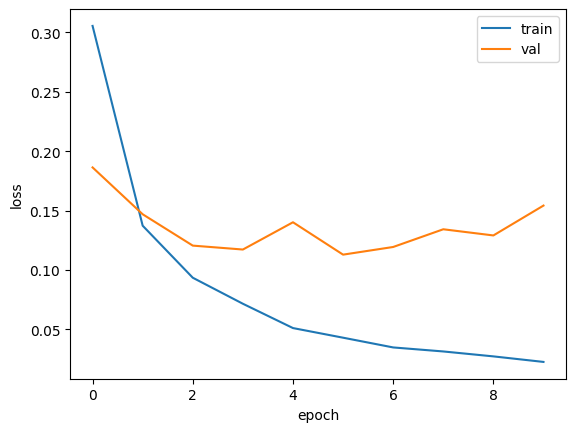

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

과대적합. 훈련데이터 성능은 좋으나, 검증데이터 성능은 좋지 못하다.

과대적합 문제는 어떻게 해결해야하나?

## **3) 드롭아웃**

In [ ]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5)

model = keras.Sequential(name = "MNist")
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1"))
model.add(keras.layers.Dropout(0.3)) # 드롭아웃 이용 층 드롭아웃 30%
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2"))
model.add(keras.layers.Dropout(0.2)) # 드롭아웃 이용 층 드롭아웃 20%
model.add(keras.layers.Dense(10, activation='softmax', name = "output"))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

In [ ]:
model.summary()

Model: "MNist"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 784)               0         
                                                                 
 hidden_1 (Dense)            (None, 256)               200960    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 hidden_2 (Dense)            (None, 64)                16448     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 output (Dense)              (None, 10)                650       
                                                                 
Total params: 218058 (851.79 KB)
Trainable params: 218058 (85

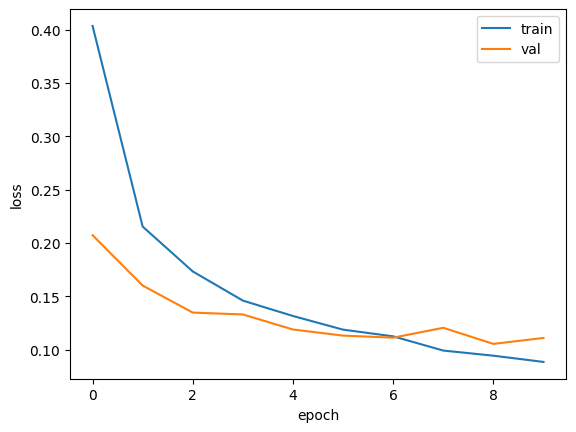

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

'옵티마이저'만 설정 할 때 보다, 각 층 마다, '드롭아웃'을 이용했을때 '과대적합 문제가 개선되었다.

In [ ]:
model.evaluate(val_scaled, val_target)

938/938 [==============================] - 3s 3ms/step - loss: 0.1111 - accuracy: 0.9693


[0.11108170449733734, 0.9692999720573425]

## **4) 콜백**

In [ ]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_scaled = train_input / 255.0

from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.5)

model = keras.Sequential(name = "MNist")
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(256, activation='leaky_relu', name = "hidden_1"))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64, activation='relu', name = "hidden_2"))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(10, activation='softmax', name = "output"))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics='accuracy')

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2)

history = model.fit(train_scaled, train_target, epochs=15, verbose=0,
                    validation_data=(val_scaled, val_target),
                    callbacks=[early_stopping_cb])

In [ ]:
model.summary()

Model: "MNist"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_6 (Flatten)         (None, 784)               0         
                                                                 
 hidden_1 (Dense)            (None, 256)               200960    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 hidden_2 (Dense)            (None, 64)                16448     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 output (Dense)              (None, 10)                650       
                                                                 
Total params: 218058 (851.79 KB)
Trainable params: 218058 (85

In [ ]:
print(early_stopping_cb.stopped_epoch)

8


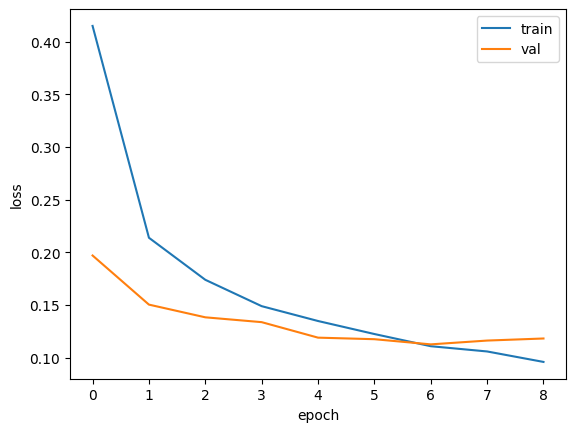

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
model.evaluate(val_scaled, val_target)

938/938 [==============================] - 2s 2ms/step - loss: 0.1181 - accuracy: 0.9681


[0.11806607246398926, 0.9680666923522949]

**참고자료 : 혼자 공부하는 머신러닝+딥러닝 박해선 지음 (한빛미디어)**